In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

Przygotowanie danych
1.1. Wczytanie danych, sprawdzenie typów danych i kompletności danych, podstawowe statystyki.

In [116]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


1.2. Utworzenie wykresu słupkowego:
1.2.1. ilości wystąpień kategorii dotyczącej atrybutu decyzyjnego,
1.2.2. atrybut decyzyjny według płci.

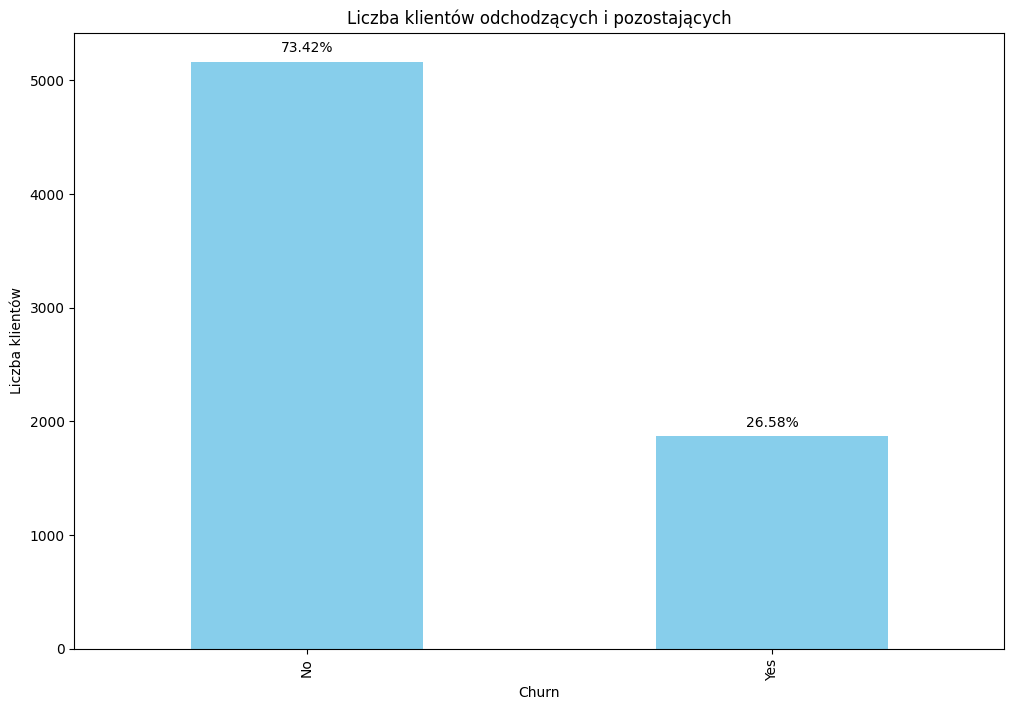

In [117]:
churn_counts = df['Churn'].value_counts()
ax = churn_counts.plot(kind='bar', color='skyblue', figsize=(12,8))
plt.title('Liczba klientów odchodzących i pozostających')
plt.xlabel('Churn')
plt.ylabel('Liczba klientów')

total = churn_counts.sum()
for p in ax.patches:
    ax.annotate(f'{(p.get_height() / total * 100):.2f}%', (p.get_x() + p.get_width() / 2, p.get_height()), 
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom')
plt.show()


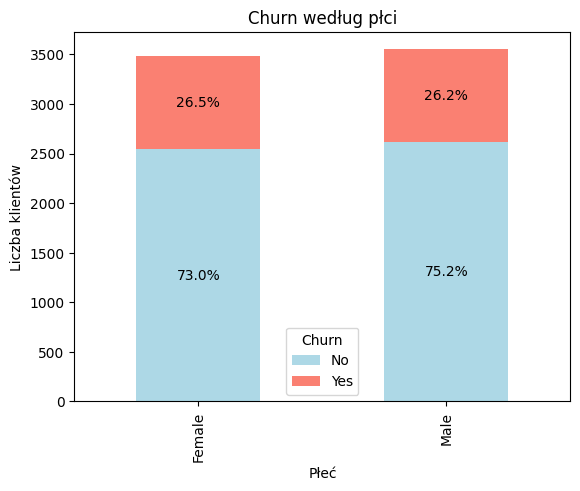

In [118]:

churn_by_gender = df.groupby(['gender', 'Churn']).size().unstack()
ax = churn_by_gender.plot(kind='bar', stacked=True, color=['lightblue', 'salmon'])

plt.title('Churn według płci')
plt.xlabel('Płeć')
plt.ylabel('Liczba klientów')

total_per_gender = churn_by_gender.sum(axis=1)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    width = p.get_width()
    x = p.get_x() + width / 2
    y = p.get_y() + height / 2
    gender = churn_by_gender.index[i // 2]
    percentage = (height / total_per_gender[gender]) * 100
    ax.annotate(f'{percentage:.1f}%', (x, y), ha='center', va='center')

plt.show()


1.3. Wykres pudełkowy:
1.3.1. opłat całkowitych w zależności od klientów, którzy odeszli w ciągu ostatniego miesiąca.
1.3.2. ‘churn’ klientów w zależności długości czasu korzystania z usług.

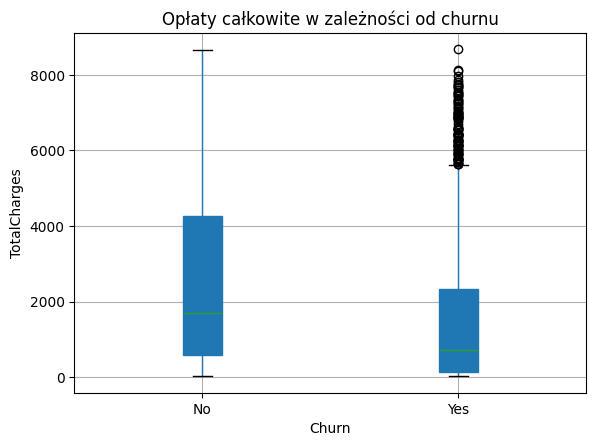

In [119]:
df.boxplot(column='TotalCharges', by='Churn', patch_artist=True)
plt.title('Opłaty całkowite w zależności od churnu')
plt.suptitle('')
plt.ylabel('TotalCharges')
plt.show()


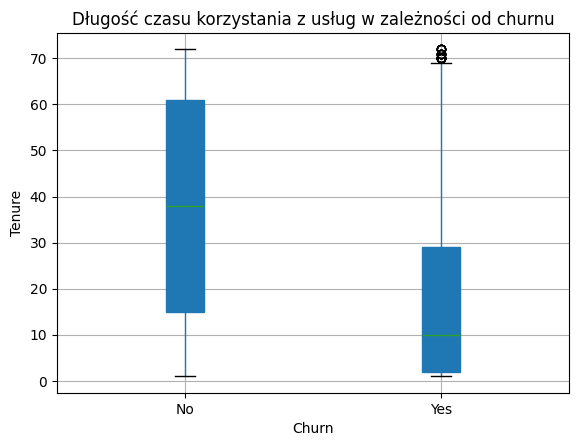

In [120]:
df.boxplot(column='tenure', by='Churn', patch_artist=True)
plt.title('Długość czasu korzystania z usług w zależności od churnu')
plt.suptitle('')
plt.ylabel('Tenure')
plt.show()


1.4. Wykres pudełkowy opłat całkowitych w zależności od rodzaju umowy z uwzględnieniem, klientów,
którzy odeszli w ciągu ostatniego miesiąca 'Churn'.

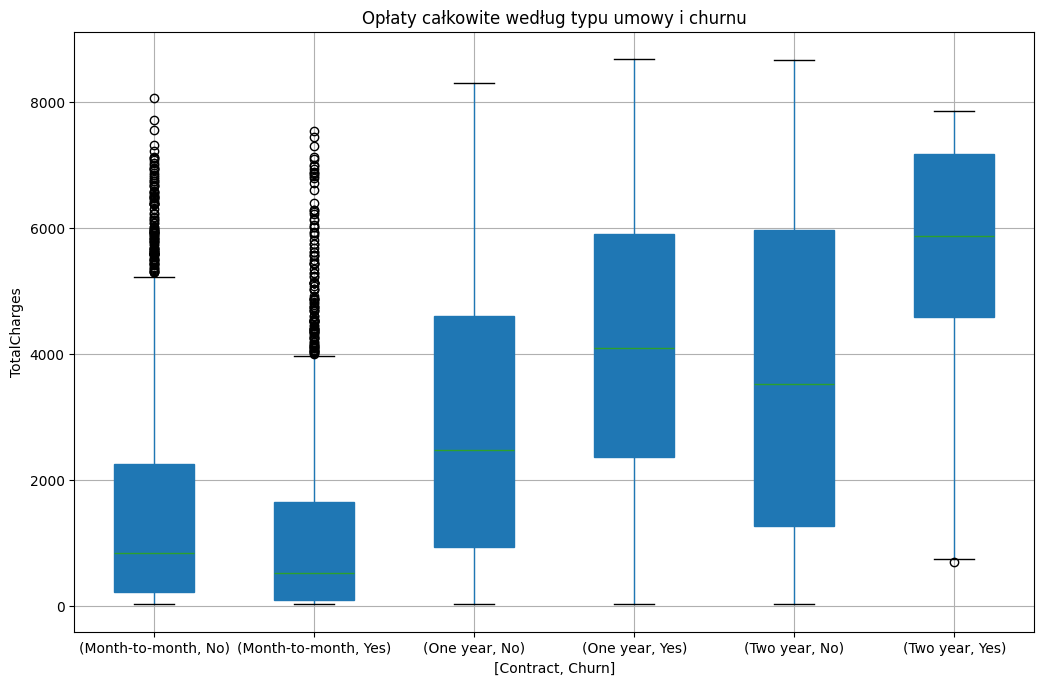

In [121]:

df.boxplot(column='TotalCharges', by=['Contract', 'Churn'], patch_artist=True, figsize=(12,8))
plt.title('Opłaty całkowite według typu umowy i churnu')
plt.suptitle('')
plt.ylabel('TotalCharges')
plt.show()


1.5. Utworzenie wykresu słupkowego wielkości korelacji z wyłączeniem cech ('customerID', 'tenure',
'MonthlyCharges', 'TotalCharges') z ‘Churn’ yes. Niektóre kolumny kategorialne należy
przekonwertować na zmienne fikcyjne.

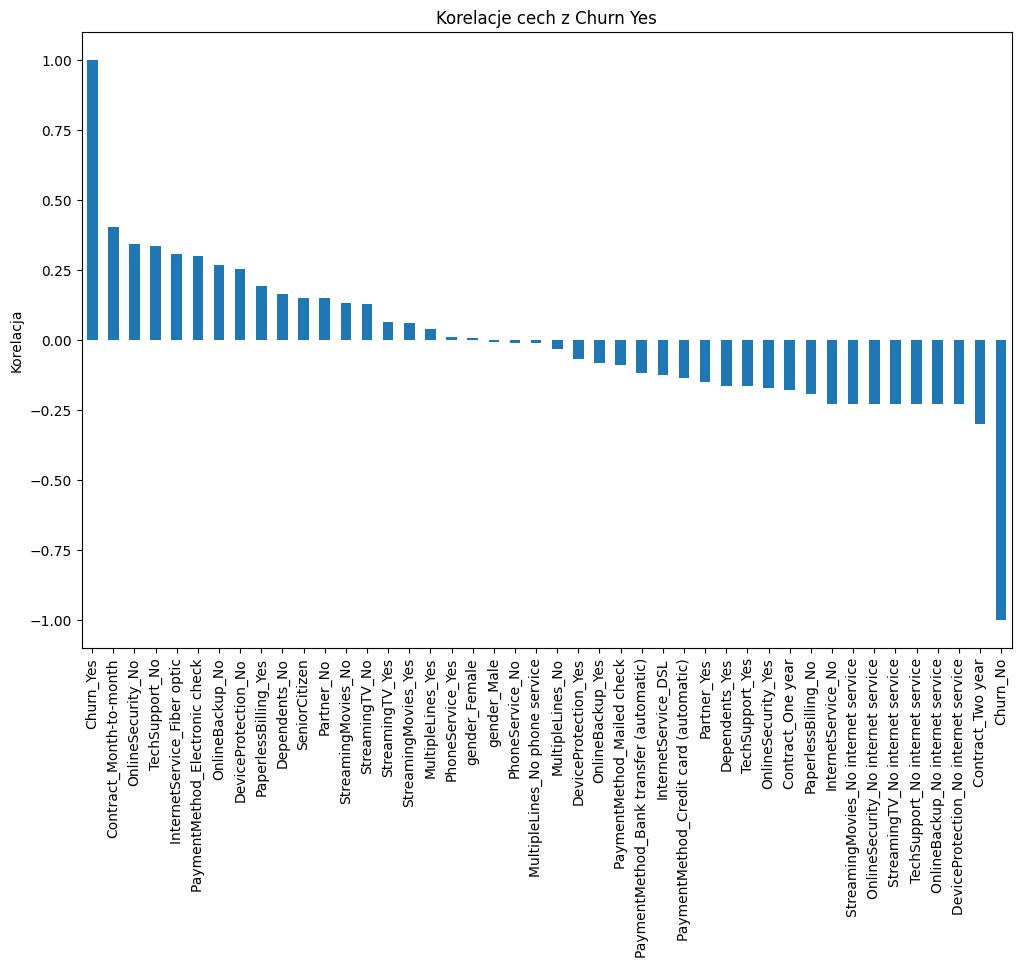

In [122]:
df_corr = df.drop(columns=['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'])

df_corr = pd.get_dummies(df_corr, drop_first=False)
plt.figure(figsize=(12,8))
correlations = df_corr.corr()['Churn_Yes'].sort_values(ascending=False)
correlations.plot(kind='bar')

plt.title('Korelacje cech z Churn Yes')
plt.ylabel('Korelacja')
plt.show()


1.6. Jakie są rodzaje zawieranych umów?

In [123]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

1.7. Rozkład różnych usług używanych przez klientów.

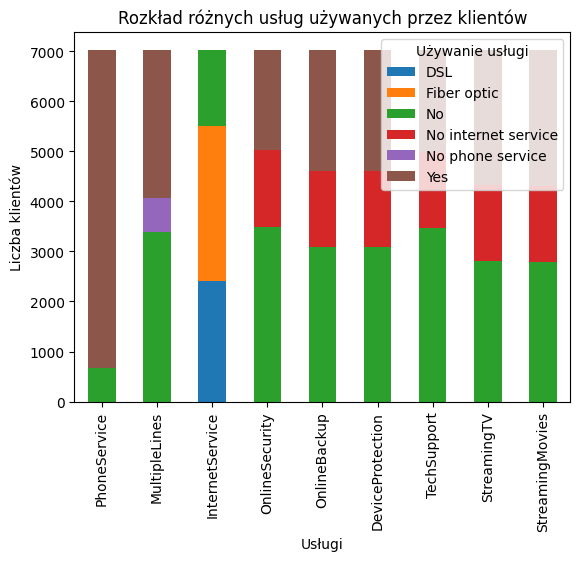

In [124]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_usage = df[services].apply(pd.Series.value_counts).T
service_usage.plot(kind='bar', stacked=True)
plt.title('Rozkład różnych usług używanych przez klientów')
plt.xlabel('Usługi')
plt.ylabel('Liczba klientów')
plt.legend(title='Używanie usługi', loc='upper right')
plt.show()

1.8. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure').
1.9. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure'), z różnicowaniem według klientów, którzy odeszli w ciągu ostatniego miesiąca oraz typu
umowy.

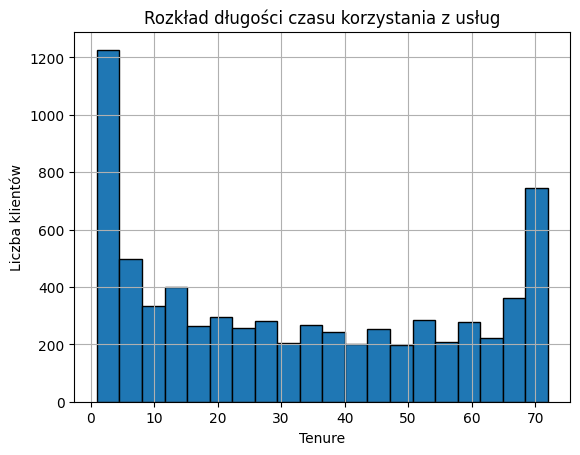

In [125]:
df['tenure'].hist(bins=20, edgecolor = 'black')
plt.title('Rozkład długości czasu korzystania z usług')
plt.xlabel('Tenure')
plt.ylabel('Liczba klientów')
plt.show()


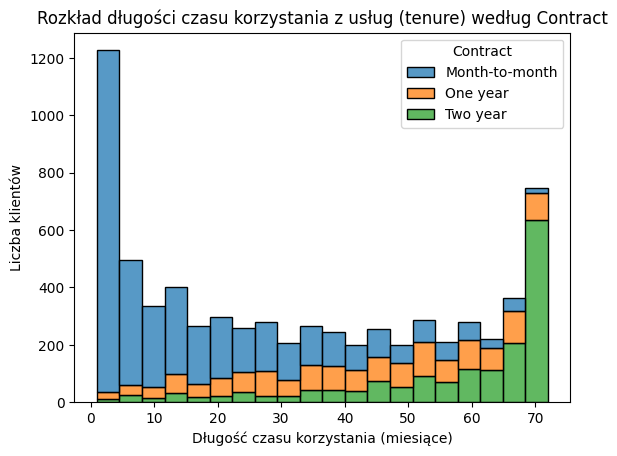

In [126]:
sns.histplot(data=df, x='tenure', hue='Contract', multiple='stack', kde=False, bins=20)
plt.title('Rozkład długości czasu korzystania z usług (tenure) według Contract')
plt.xlabel('Długość czasu korzystania (miesiące)')
plt.ylabel('Liczba klientów')
plt.show()


1.10. Traktując każdą unikalną grupę 'tenure' jako kohortę (kohorta to grupa klientów, którzy mają
wspólną cechę w określonym czasie. W kontekście analizy danych dotyczących churnu, kohorta może
być definiowana na podstawie długości czasu korzystania z usług firmy), należy obliczyć współczynnik
rezygnacji (procent osób, które zadeklarowały rezygnację) dla każdej kohorty. Na przykład w kohorcie
z 1-miesięcznym stażem wskaźnik rezygnacji wynosi 61,99%. Kohorty powinny obejmować staż od 1
do 72 miesięcy, z ogólną tendencją, że im dłuższy czasu korzystania z usług, tym niższy współczynnik
rezygnacji.

In [127]:
cohort_churn_rate = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
cohort_churn_rate = cohort_churn_rate.reset_index()
cohort_churn_rate.columns = ['Tenure', 'Churn Rate (%)']
cohort_churn_rate

,Tenure,Churn Rate (%)
0,1,61.990212
1,2,51.680672
2,3,47.000000
3,4,47.159091
4,5,48.120301
...,...,...
67,68,9.000000
68,69,8.421053
69,70,9.243697
70,71,3.529412


1.11. Wykres zależności współczynnika rezygnacji od 'tenure' w miesiącach.

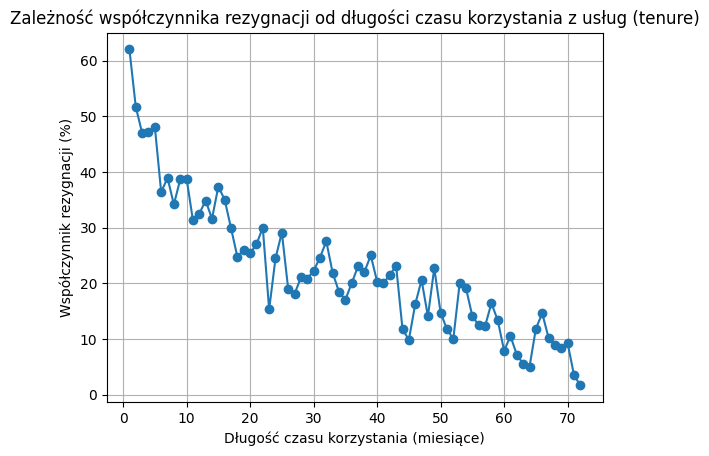

In [128]:
plt.plot(cohort_churn_rate['Tenure'], cohort_churn_rate['Churn Rate (%)'], marker='o')
plt.title('Zależność współczynnika rezygnacji od długości czasu korzystania z usług (tenure)')
plt.xlabel('Długość czasu korzystania (miesiące)')
plt.ylabel('Współczynnik rezygnacji (%)')
plt.grid(True)
plt.show()

1.12. Na podstawie wartości kolumny 'tenure' należy stworzyć nową kolumnę, dzieląc 'tenure' na 4
grupy: '0-12 miesięcy, '12-24 miesięcy, '24-48 miesięcy, ‘Powyżej 48 miesięcy’.

In [129]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12 miesięcy', '12-24 miesiące', '24-48 miesięcy', 'Powyżej 48 miesięcy'])

1.13. Wykres pudełkowy długości czasu korzystania z usług ('tenure') podzielony na 4 grupy w
zależności od 'Churn'.

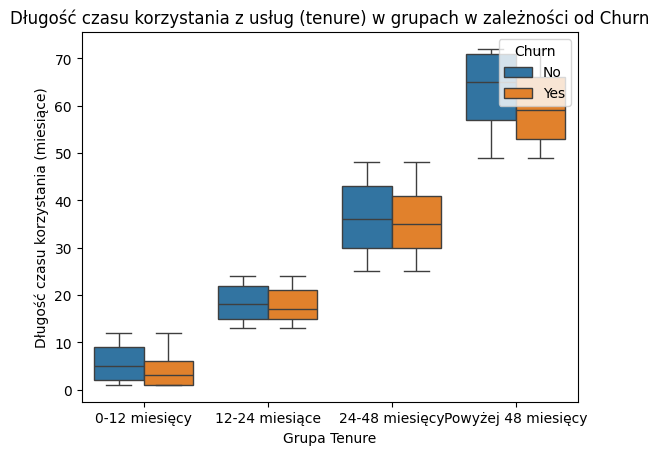

In [130]:
sns.boxplot(x='tenure_group', y='tenure', hue='Churn', data=df)
plt.title('Długość czasu korzystania z usług (tenure) w grupach w zależności od Churn')
plt.xlabel('Grupa Tenure')
plt.ylabel('Długość czasu korzystania (miesiące)')
plt.legend(title='Churn', loc='upper right')
plt.show()

Podział zbioru
2.1. Podział danych na macierz cech oraz etykiety. Należy stworzyć obiekt DataFrame z odpowiednimi
zmiennymi fikcyjnymi. Należy pamiętać, że niektóre kolumny można pominąć.
2.2. Podział zbioru danych na treningowy i testowy, z ustawionym random_state=42, tak aby zbiór
testowy zawierał co najmniej 1100 przykładów.

In [131]:
df = df.drop(columns=['customerID', 'tenure'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, columns=['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                                  'TechSupport', 'StreamingTV', 'StreamingMovies', 
                                  'InternetService', 'Contract', 'PaymentMethod', 'tenure_group'], 
                     drop_first=True)

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(5625, 32) (1407, 32) (5625,) (1407,)


3. Model drzewa decyzyjnego
3.1. Zastosowanie klasyfikatora drzewa decyzyjnego przy ustawieniach domyślnych.
3.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów i drzewo decyzyjne na podstawie
predykcji na zbiorze testowym.
3.3. Informacja nt. wagi cech.

In [132]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407

[[846 187]
 [187 187]]


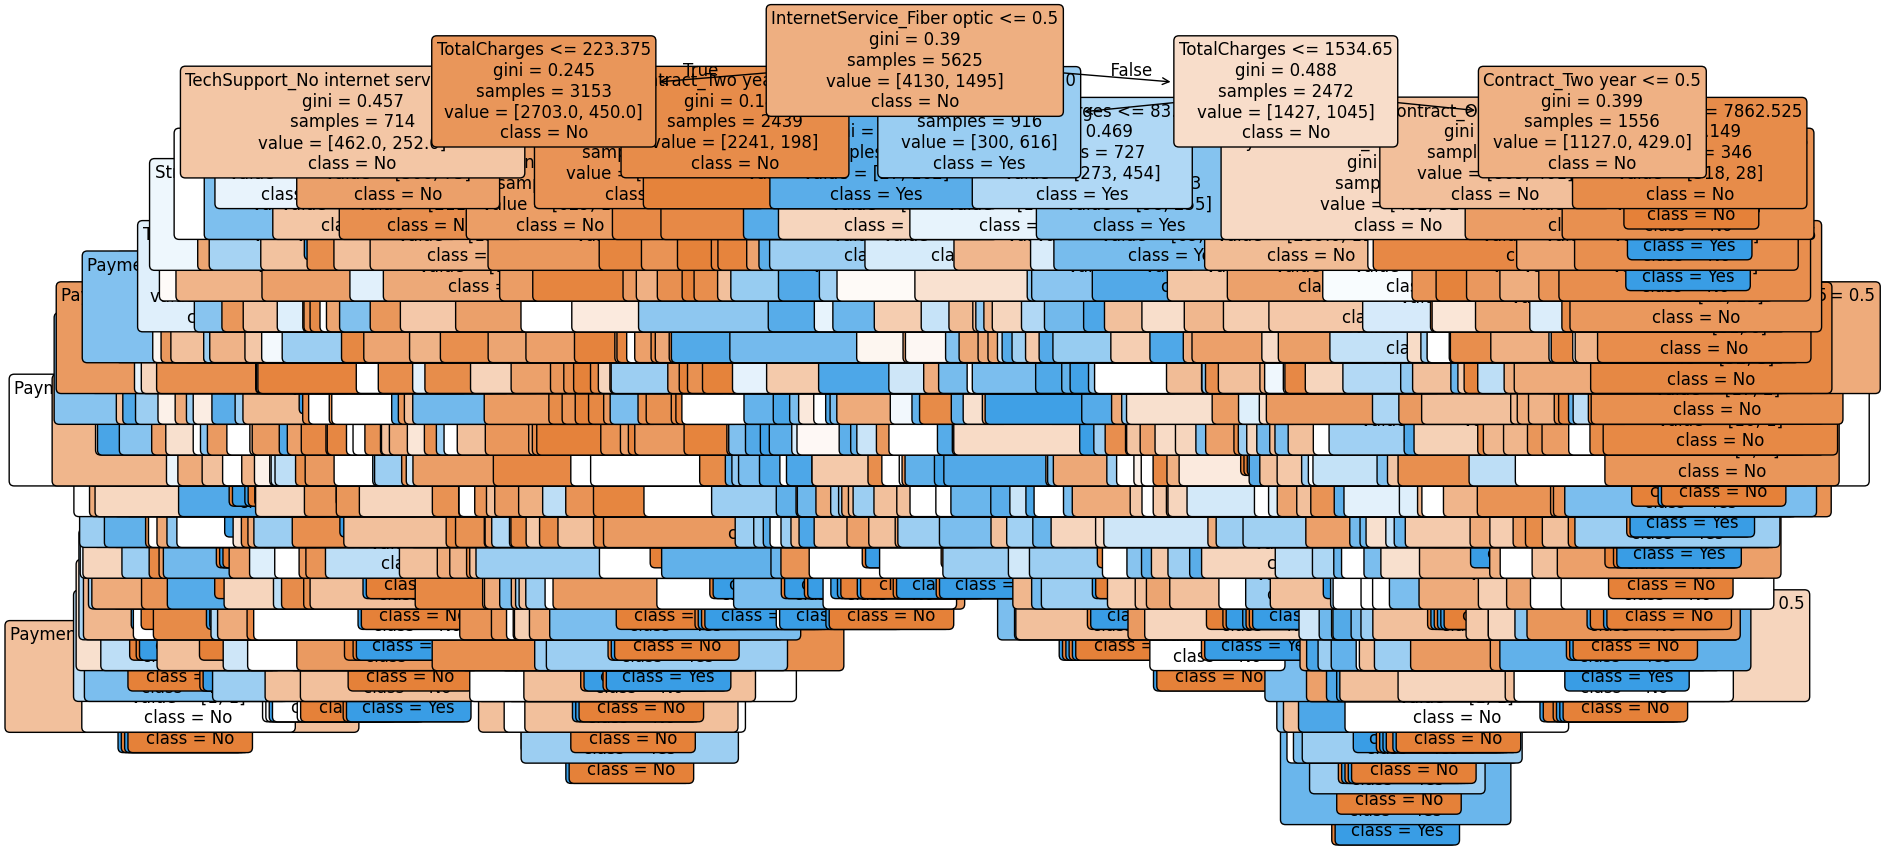

In [133]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['No', 'Yes'], rounded=True, fontsize=12)
plt.title("Drzewo decyzyjne")
plt.show()


                                  Feature  Importance
7                            TotalCharges    0.345417
6                          MonthlyCharges    0.212512
22            InternetService_Fiber optic    0.099629
3                              Dependents    0.025123
0                                  gender    0.024561
2                                 Partner    0.023229
25                      Contract_Two year    0.022820
5                        PaperlessBilling    0.021983
24                      Contract_One year    0.021003
15                   DeviceProtection_Yes    0.019841
13                       OnlineBackup_Yes    0.019135
16        TechSupport_No internet service    0.018252
9                       MultipleLines_Yes    0.018163
27         PaymentMethod_Electronic check    0.018131
1                           SeniorCitizen    0.016572
11                     OnlineSecurity_Yes    0.016299
28             PaymentMethod_Mailed check    0.015829
21                    Stream

<Figure size 1200x800 with 0 Axes>

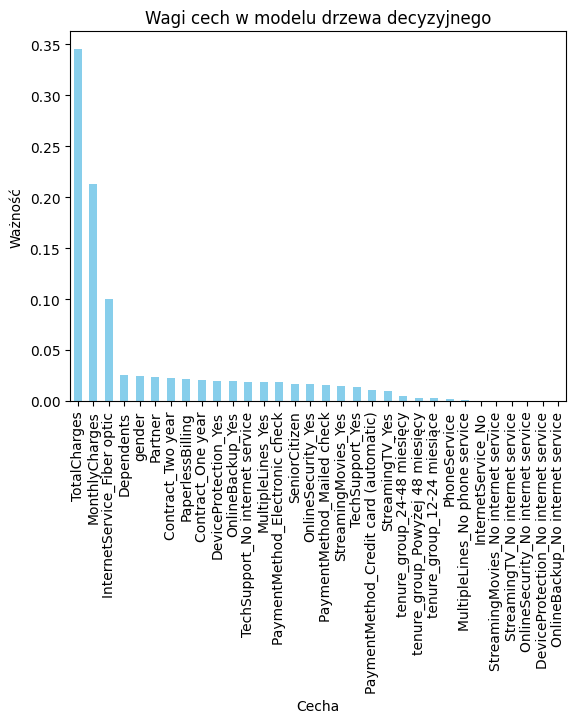

In [134]:
feature_importances = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)
plt.figure(figsize=(12, 8))

importance_df.plot(kind='bar', x='Feature', y='Importance', legend=False, color='skyblue')
plt.title('Wagi cech w modelu drzewa decyzyjnego')
plt.xlabel('Cecha')
plt.ylabel('Ważność')
plt.xticks(rotation=90)
plt.show()


4. Model k-najbliższych sąsiadów
4.1. Zastosowanie klasyfikatora k-najbliższych sąsiadów przy ustawieniach domyślnych.
4.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [135]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.59      0.45      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407

[[917 116]
 [206 168]]


5. Model regresji logistycznej
5.1. Zastosowanie klasyfikatora regresji logistycznej przy ustawieniach domyślnych.
5.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [136]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407

[[934  99]
 [203 171]]


Optymalizacja modeli

In [137]:
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)


best_dt = grid_dt.best_params_, grid_dt.best_score_
print('Najlepsze parametry', best_dt)

best_dt_model = grid_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test)

print("Raport z klasyfikacji dla drzewa decyzyjnego zoptymalizowanego:")
print(classification_report(y_test, y_pred_dt))

print("Macierz błędów dla drzewa decyzyjnego zoptymalizowanego:")
print(confusion_matrix(y_test, y_pred_dt))


Najlepsze parametry ({'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.7888)
Raport z klasyfikacji dla drzewa decyzyjnego zoptymalizowanego:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

Macierz błędów dla drzewa decyzyjnego zoptymalizowanego:
[[911 122]
 [183 191]]


                                  Feature  Importance
7                            TotalCharges    0.477163
22            InternetService_Fiber optic    0.371131
25                      Contract_Two year    0.083714
16        TechSupport_No internet service    0.067991
17                        TechSupport_Yes    0.000000
30            tenure_group_24-48 miesięcy    0.000000
29            tenure_group_12-24 miesiące    0.000000
28             PaymentMethod_Mailed check    0.000000
27         PaymentMethod_Electronic check    0.000000
26  PaymentMethod_Credit card (automatic)    0.000000
24                      Contract_One year    0.000000
23                     InternetService_No    0.000000
21                    StreamingMovies_Yes    0.000000
20    StreamingMovies_No internet service    0.000000
19                        StreamingTV_Yes    0.000000
18        StreamingTV_No internet service    0.000000
0                                  gender    0.000000
1                           

<Figure size 1200x800 with 0 Axes>

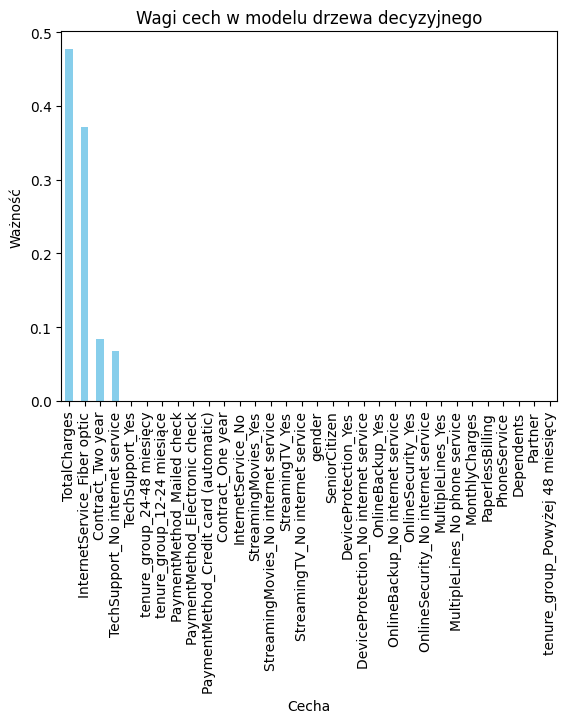

In [138]:
feature_importances_opt = best_dt_model.feature_importances_

importance_df_opt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances_opt
})

importance_df_opt = importance_df_opt.sort_values(by='Importance', ascending=False)

print(importance_df_opt)
plt.figure(figsize=(12, 8))

importance_df_opt.plot(kind='bar', x='Feature', y='Importance', legend=False, color='skyblue')
plt.title('Wagi cech w modelu drzewa decyzyjnego')
plt.xlabel('Cecha')
plt.ylabel('Ważność')
plt.xticks(rotation=90)
plt.show()


In [139]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_params_, grid_knn.best_score_
print('Najlepsze parametry', best_knn)

best_knn_model = grid_knn.best_estimator_

y_pred_knn = best_knn_model.predict(X_test)

print("Raport z klasyfikacji dla KNN zoptymalizowanego:")
print(classification_report(y_test, y_pred_knn))

print("Macierz błędów dla KNN zoptymalizowanego:")
print(confusion_matrix(y_test, y_pred_knn))

Najlepsze parametry ({'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}, 0.7827555555555555)
Raport z klasyfikacji dla KNN zoptymalizowanego:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.68      0.40      0.50       374

    accuracy                           0.79      1407
   macro avg       0.74      0.66      0.68      1407
weighted avg       0.78      0.79      0.77      1407

Macierz błędów dla KNN zoptymalizowanego:
[[962  71]
 [225 149]]


In [140]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1'],  
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500],
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_params_, grid_lr.best_score_

print('Najlepsze parametry', best_lr)

best_lr_model = grid_lr.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)

print("Raport z klasyfikacji dla Logistic Regression zoptymalizowanej:")
print(classification_report(y_test, y_pred_lr))

print("Macierz błędów dla Logistic Regression zoptymalizowanej:")
print(confusion_matrix(y_test, y_pred_lr))


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which 

Najlepsze parametry ({'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}, 0.8042666666666667)
Raport z klasyfikacji dla Logistic Regression zoptymalizowanej:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407

Macierz błędów dla Logistic Regression zoptymalizowanej:
[[943  90]
 [205 169]]


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
